# Problem set 5

For the remainder of the semester, we will focus on problems addressed in or inspired by [Hu and Fu (2007)](https://doi.org/10.5194/acp-7-5229-2007). In their paper, Hu and Fu (2007) evaluate the expansion of the Hadley circulation in several reanalyses. 

In this first set, we establish the foundations for further analysis by developing a method for calculating the meridional mass streamfunction and plotting its changes over time. I recommend using [xarray](https://docs.xarray.dev/en/stable/) to do this (see this week's python examples).

**5-1.** Establish a method for computing the meridional mass streamfunction $\psi$:

$\psi(p) = \frac{2\pi R_e \cos(\varphi)}{g} \int_0^p [v] dp'$

where $R_e$ is the radius of the Earth, $\varphi$ is latitude, $g$ is the gravitational constant, and $[v]$ is the zonal-mean meridional wind (i.e., the northward wind averaged over all longitudes). The meridional mass streamfunction $\psi$ provides a measure of the strength and extent of the overturning Hadley cell. 

**(a)** Calculate the time mean of the zonal-mean northward wind ($[\bar{v}]$) based on your reanalysis (see xarray examples for hints).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy import integrate

DATA_PATH = Path("data/ERA5_zonal_common-grid_monthly_core_1950-2024.nc")
EARTH_RADIUS = 6.371e6  # m
GRAVITY = 9.80665  # m/s^2

ds = xr.open_dataset(DATA_PATH)
v = ds["v"]
v_zm_mean = v.mean("time")
v_zm_mean  # m/s

<xarray.DataArray 'v' (lat: 73, pre: 22)> Size: 6kB
array([[ 7.46555850e-02,  7.43933544e-02,  7.49036521e-02, ...,
         1.08526662e-01,  1.26482829e-01,  1.48385465e-01],
       [ 1.56716955e+00,  1.56729996e+00,  1.56823409e+00, ...,
         4.85093426e-03,  7.88083673e-03,  3.59210139e-03],
       [ 9.56445932e-01,  1.02141964e+00,  9.24167633e-01, ...,
        -2.41445308e-03,  1.02426745e-02, -7.41281454e-03],
       ...,
       [ 4.08178270e-02,  2.71679666e-02, -1.23206922e-03, ...,
        -1.54234126e-01, -2.01026514e-01, -2.44236618e-01],
       [ 7.62143871e-03,  1.30289337e-02,  3.12147452e-03, ...,
        -8.04500356e-02, -1.07274629e-01, -1.23673014e-01],
       [-1.42879896e-02, -1.39544364e-02, -8.93238559e-03, ...,
        -1.23520888e-01, -9.02809575e-02, -1.94011033e-02]],
      shape=(73, 22), dtype=float32)
Coordinates:
  * lat      (lat) float64 584B -90.0 -87.5 -85.0 -82.5 ... 82.5 85.0 87.5 90.0
  * pre      (pre) int32 88B 100000 92500 85000 70000 60000 ... 500 300 200 100
Attributes:
    standard_name:  northward_wind
    units:          m s-1
    description:    Northward wind
    latex_name:     $\overline{v}$

**(b)** Use the time-mean $[\bar{v}]$ calculated in part (a) to compute $\psi(p)$ using a cumulative integral, starting from the top of the atmosphere and integrating to each pressure level $p$. Note: the equation above assumes $p$ in Pascals. If the pressure dimension of your data is in hectoPascals (hPa) you will need to multiply the result by 100. 

In [2]:
pre_sorted = v_zm_mean.sortby("pre").transpose("lat", "pre")
pre = pre_sorted["pre"]

# Sort from low to high pressure so the cumulative integral starts near the TOA.
v_int = xr.apply_ufunc(
    integrate.cumulative_trapezoid,
    pre_sorted,
    pre,
    input_core_dims=[["pre"], ["pre"]],
    output_core_dims=[["pre"]],
    kwargs={"axis": -1, "initial": 0.0},
    vectorize=True,
)
v_int = v_int.assign_coords({"pre": pre}).transpose("lat", "pre")  # kg/s^3

prefactor = 2 * np.pi * EARTH_RADIUS * np.cos(np.deg2rad(pre_sorted["lat"])) / GRAVITY  # s^2
psi = prefactor * v_int
psi  # kg/s

<xarray.DataArray (lat: 73, pre: 22)> Size: 13kB
array([[ 0.00000000e+00,  3.43512330e-09,  6.37211731e-09, ...,
        -1.98836953e-07, -5.89007780e-08,  8.08028908e-08],
       [ 0.00000000e+00,  1.02138866e+05,  2.15484601e+05, ...,
         4.09082184e+09,  6.18439986e+09,  8.27726708e+09],
       [ 0.00000000e+00,  5.03382085e+04,  1.89588440e+05, ...,
         5.62541071e+08,  3.15818306e+09,  5.79688810e+09],
       ...,
       [ 0.00000000e+00, -7.92044463e+06, -1.42399037e+07, ...,
        -1.85507099e+08, -1.50905564e+08, -6.02045265e+07],
       [ 0.00000000e+00, -2.05603214e+06, -3.72726783e+06, ...,
        -3.57763929e+07, -2.49928589e+07, -1.12047246e+07],
       [ 0.00000000e+00, -1.37073424e-09, -4.04268905e-09, ...,
         3.98865097e-08,  1.84346764e-08, -8.03696802e-09]],
      shape=(73, 22))
Coordinates:
  * lat      (lat) float64 584B -90.0 -87.5 -85.0 -82.5 ... 82.5 85.0 87.5 90.0
  * pre      (pre) int32 88B 100 200 300 500 700 ... 70000 85000 92500 100000
Attributes:
    long_name:    latitude
    axis:         Y
    description:  Northward wind
    latex_name:   $\overline{v}$

Hint: [DataArray.reduce](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.reduce.html) can be used with integration schemes from [scipy](https://docs.scipy.org/doc/scipy/reference/integrate.html). Remember that you want to use a cumulative integration scheme!

**(c)** Plot the meridional mass streamfunction as a function of latitude and pressure. See this [annual cycle animation](https://commons.wikimedia.org/wiki/File:1991-2020_NCEP-NCAR_reanalysis_1_Hadley_cell_stream_function.gif) based on the NCEP-NCAR reanalysis to check the magnitude of your result (should be 10$^{11}$ kg/s).

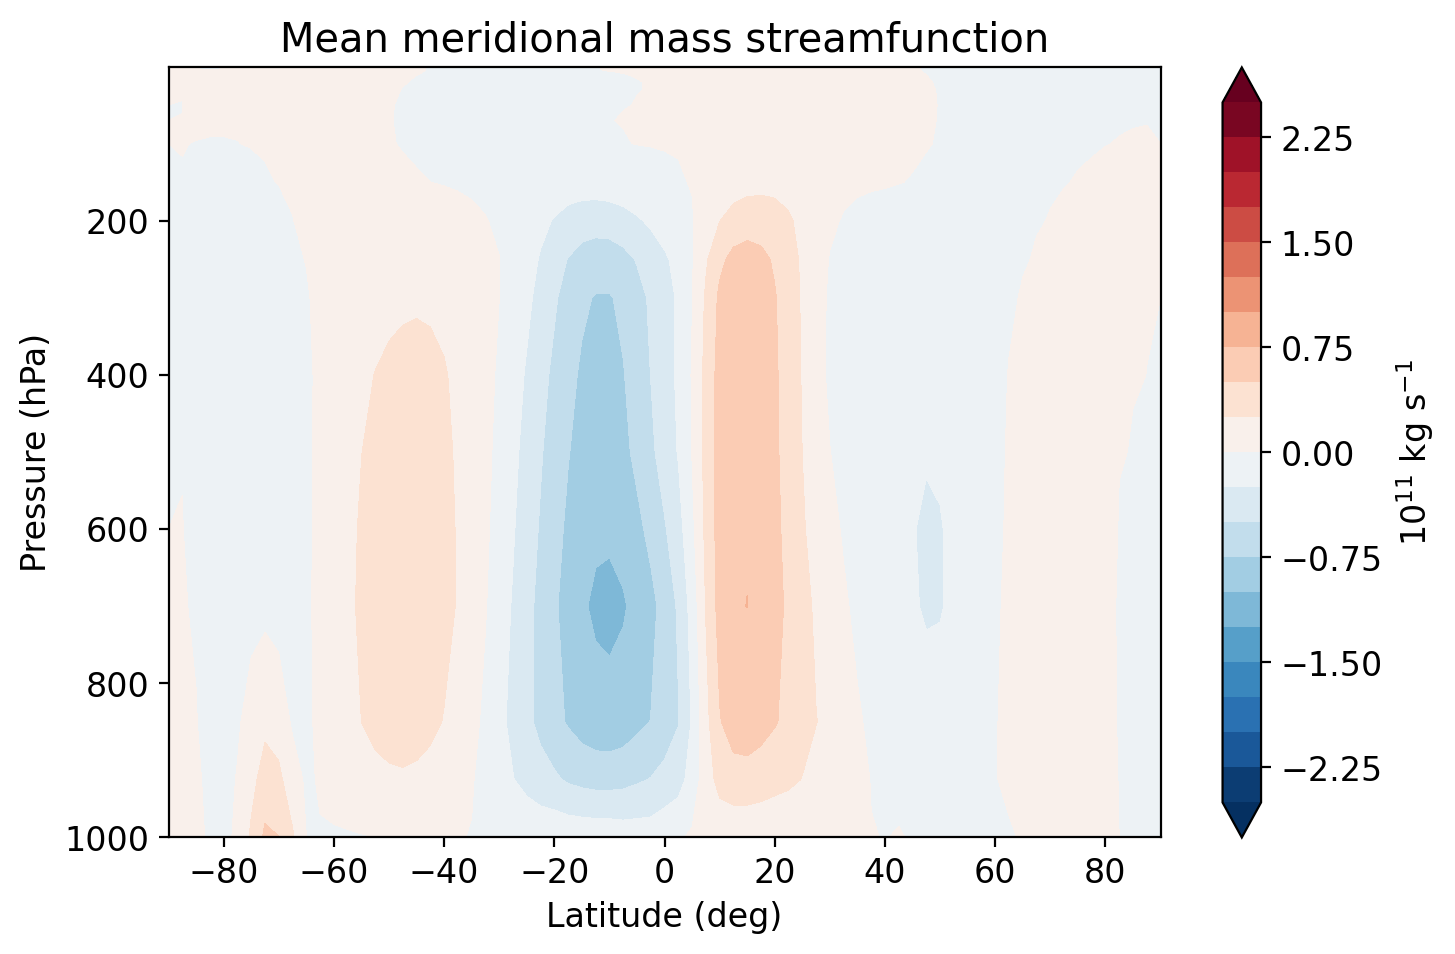

In [3]:
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 0.8,
    "figure.dpi": 200,
})

psi_plot = psi / 1e11
pre_hpa = psi_plot["pre"] / 100.0
levels = np.linspace(-2.5, 2.5, 21)

fig, ax = plt.subplots(figsize=(8, 5))
cf = ax.contourf(
    psi_plot["lat"],
    pre_hpa,
    psi_plot.transpose("pre", "lat"),
    levels=levels,
    cmap="RdBu_r",
    extend="both",
)
ax.invert_yaxis()
ax.set_xlabel("Latitude (deg)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Mean meridional mass streamfunction")
fig.colorbar(cf, ax=ax, label=r"$10^{11}$ kg s$^{-1}$")
plt.show()

**5-2** Plot the changes in the strength of the meridional mass streamfunction over time, as in Fig. 1 of [Hu and Fu (2007)](https://doi.org/10.5194/acp-7-5229-2007).

**(a)** Extract the months of September-November (autumn in the Northern Hemisphere, or boreal autumn) from the full time series of the zonal-mean northward wind $[v]$ and calculate a time series of yearly averages. 

In [4]:
# SON.
v_son = v.sel(time=v["time"].dt.month.isin([9, 10, 11]))
v_son_mean = v_son.groupby("time.year").mean("time")
v_son_mean

<xarray.DataArray 'v' (year: 75, lat: 73, pre: 22)> Size: 482kB
array([[[ 1.14301809e-04,  1.63903205e-05,  8.03884250e-05, ...,
          4.57116148e-05, -2.02515712e-05,  7.12499022e-05],
        [ 1.42368460e+00,  1.42541945e+00,  1.42776024e+00, ...,
          1.06652088e-01,  3.01325824e-02, -1.32424638e-01],
        [ 1.04873550e+00,  1.11881602e+00,  9.78494942e-01, ...,
          6.03558235e-02,  5.99717908e-02, -8.07732716e-02],
        ...,
        [-1.28950521e-01, -3.78728099e-02, -2.33540088e-02, ...,
         -1.49622336e-01, -1.25565633e-01, -3.42599601e-02],
        [-1.36645600e-01, -3.29412818e-02, -1.60453580e-02, ...,
         -7.31344745e-02, -8.31187591e-02,  7.66936094e-02],
        [ 1.14301809e-04,  1.63903205e-05,  8.03884250e-05, ...,
          4.57116148e-05, -2.02515712e-05,  7.12499022e-05]],

       [[ 5.96561331e-05,  8.95236808e-05,  7.80632763e-05, ...,
          5.24097413e-05,  6.43000458e-05,  3.19725700e-06],
        [ 1.59075654e+00,  1.59271586e+00,  1.59517622e+00, ...,
         -7.20992014e-02,  3.61074284e-02, -4.62522916e-02],
        [ 1.07041085e+00,  1.13936293e+00,  1.01542938e+00, ...,
         -1.96715500e-02,  3.01386397e-02, -3.19874398e-02],
...
          3.43052857e-02, -1.09585784e-01, -2.74166822e-01],
        [-1.55441299e-01, -5.04976362e-02, -2.98663918e-02, ...,
          5.94784319e-02, -1.46865904e-01, -1.15368068e-01],
        [-7.72075951e-01, -1.57762623e+00, -1.56262636e+00, ...,
         -4.02585077e+00, -3.85827708e+00, -2.61647868e+00]],

       [[ 2.36048150e+00,  2.35113883e+00,  2.36543798e+00, ...,
          1.35893326e+01,  1.45452309e+01,  1.45801649e+01],
        [ 1.64738071e+00,  1.64796984e+00,  1.64951181e+00, ...,
          3.55048217e-02,  1.43259197e-01,  1.72428846e-01],
        [ 1.06570697e+00,  1.12878740e+00,  1.04163837e+00, ...,
          1.03784569e-01,  2.81389356e-01,  3.44522119e-01],
        ...,
        [-5.91857433e-02,  4.79175337e-02,  3.83584504e-03, ...,
         -8.63139629e-02, -1.68035924e-01, -2.40755931e-01],
        [-7.45205721e-03,  4.89522070e-02,  4.13952358e-02, ...,
         -2.59647220e-02, -9.38755497e-02, -1.63968399e-01],
        [-5.08265913e-01, -6.86425209e-01, -7.77864635e-01, ...,
         -2.44822001e+00, -1.17565453e+00,  2.03288126e+00]]],
      shape=(75, 73, 22), dtype=float32)
Coordinates:
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
  * lat      (lat) float64 584B -90.0 -87.5 -85.0 -82.5 ... 82.5 85.0 87.5 90.0
  * pre      (pre) int32 88B 100000 92500 85000 70000 60000 ... 500 300 200 100
Attributes:
    standard_name:  northward_wind
    units:          m s-1
    description:    Northward wind
    latex_name:     $\overline{v}$

**(b)** Calculate the year-by-year time series of meridional mass streamfunction and extract the values on the 500 hPa pressure surface (note: here you could also replace the cumulative integral with a single integral from the top-of-atmosphere to 500 hPa).

In [5]:
# Repeat the cumulative integration for each yearly SON mean.
v_son_sorted = v_son_mean.sortby("pre").transpose("year", "lat", "pre")
pre = v_son_sorted["pre"]

v_son_int = xr.apply_ufunc(
    integrate.cumulative_trapezoid,
    v_son_sorted,
    pre,
    input_core_dims=[["pre"], ["pre"]],
    output_core_dims=[["pre"]],
    kwargs={"axis": -1, "initial": 0.0},
    vectorize=True,
)
v_son_int = v_son_int.assign_coords({"pre": pre}).transpose("year", "lat", "pre")

prefactor = 2 * np.pi * EARTH_RADIUS * np.cos(np.deg2rad(v_son_sorted["lat"])) / GRAVITY
psi_son = prefactor * v_son_int

# 50000 Pa.
psi_500 = psi_son.sel(pre=50000)
psi_500

<xarray.DataArray (lat: 73, year: 75)> Size: 44kB
array([[ 2.65064971e-10, -1.30765635e-10, -1.22226820e-10, ...,
         2.21176671e-06, -3.30163535e-05, -1.74366111e-06],
       [ 1.83283915e+08, -5.90501971e+07, -3.01388643e+07, ...,
        -6.20159004e+07,  1.01260147e+08,  5.10080282e+07],
       [-3.74495964e+08, -9.84277018e+08, -7.97056993e+08, ...,
        -8.90286491e+08,  1.46108854e+08, -3.06092578e+08],
       ...,
       [ 4.78558732e+08, -5.32328782e+08,  5.57714473e+08, ...,
         2.59707269e+08,  2.65693219e+08,  1.68258333e+08],
       [ 1.51957809e+08, -2.15595280e+08,  2.08029476e+08, ...,
         8.66846652e+07,  1.89050356e+08, -7.56418719e+07],
       [ 2.65064971e-10, -1.30765635e-10, -1.22226820e-10, ...,
         1.77311097e-05, -3.63257178e-06, -2.26443237e-05]],
      shape=(73, 75))
Coordinates:
  * lat      (lat) float64 584B -90.0 -87.5 -85.0 -82.5 ... 82.5 85.0 87.5 90.0
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
    pre      int32 4B 50000
Attributes:
    long_name:    latitude
    axis:         Y
    description:  Northward wind
    latex_name:   $\overline{v}$

**(c)** Plot the time series of boreal autumn-mean meridional mass streamfunction at 500 hPa, as in Fig. 1 of [Hu and Fu (2007)](https://doi.org/10.5194/acp-7-5229-2007). Do you see evidence of Hadley Cell expansion? Next week we will formally evaluate the trends in both the NH and SH. 

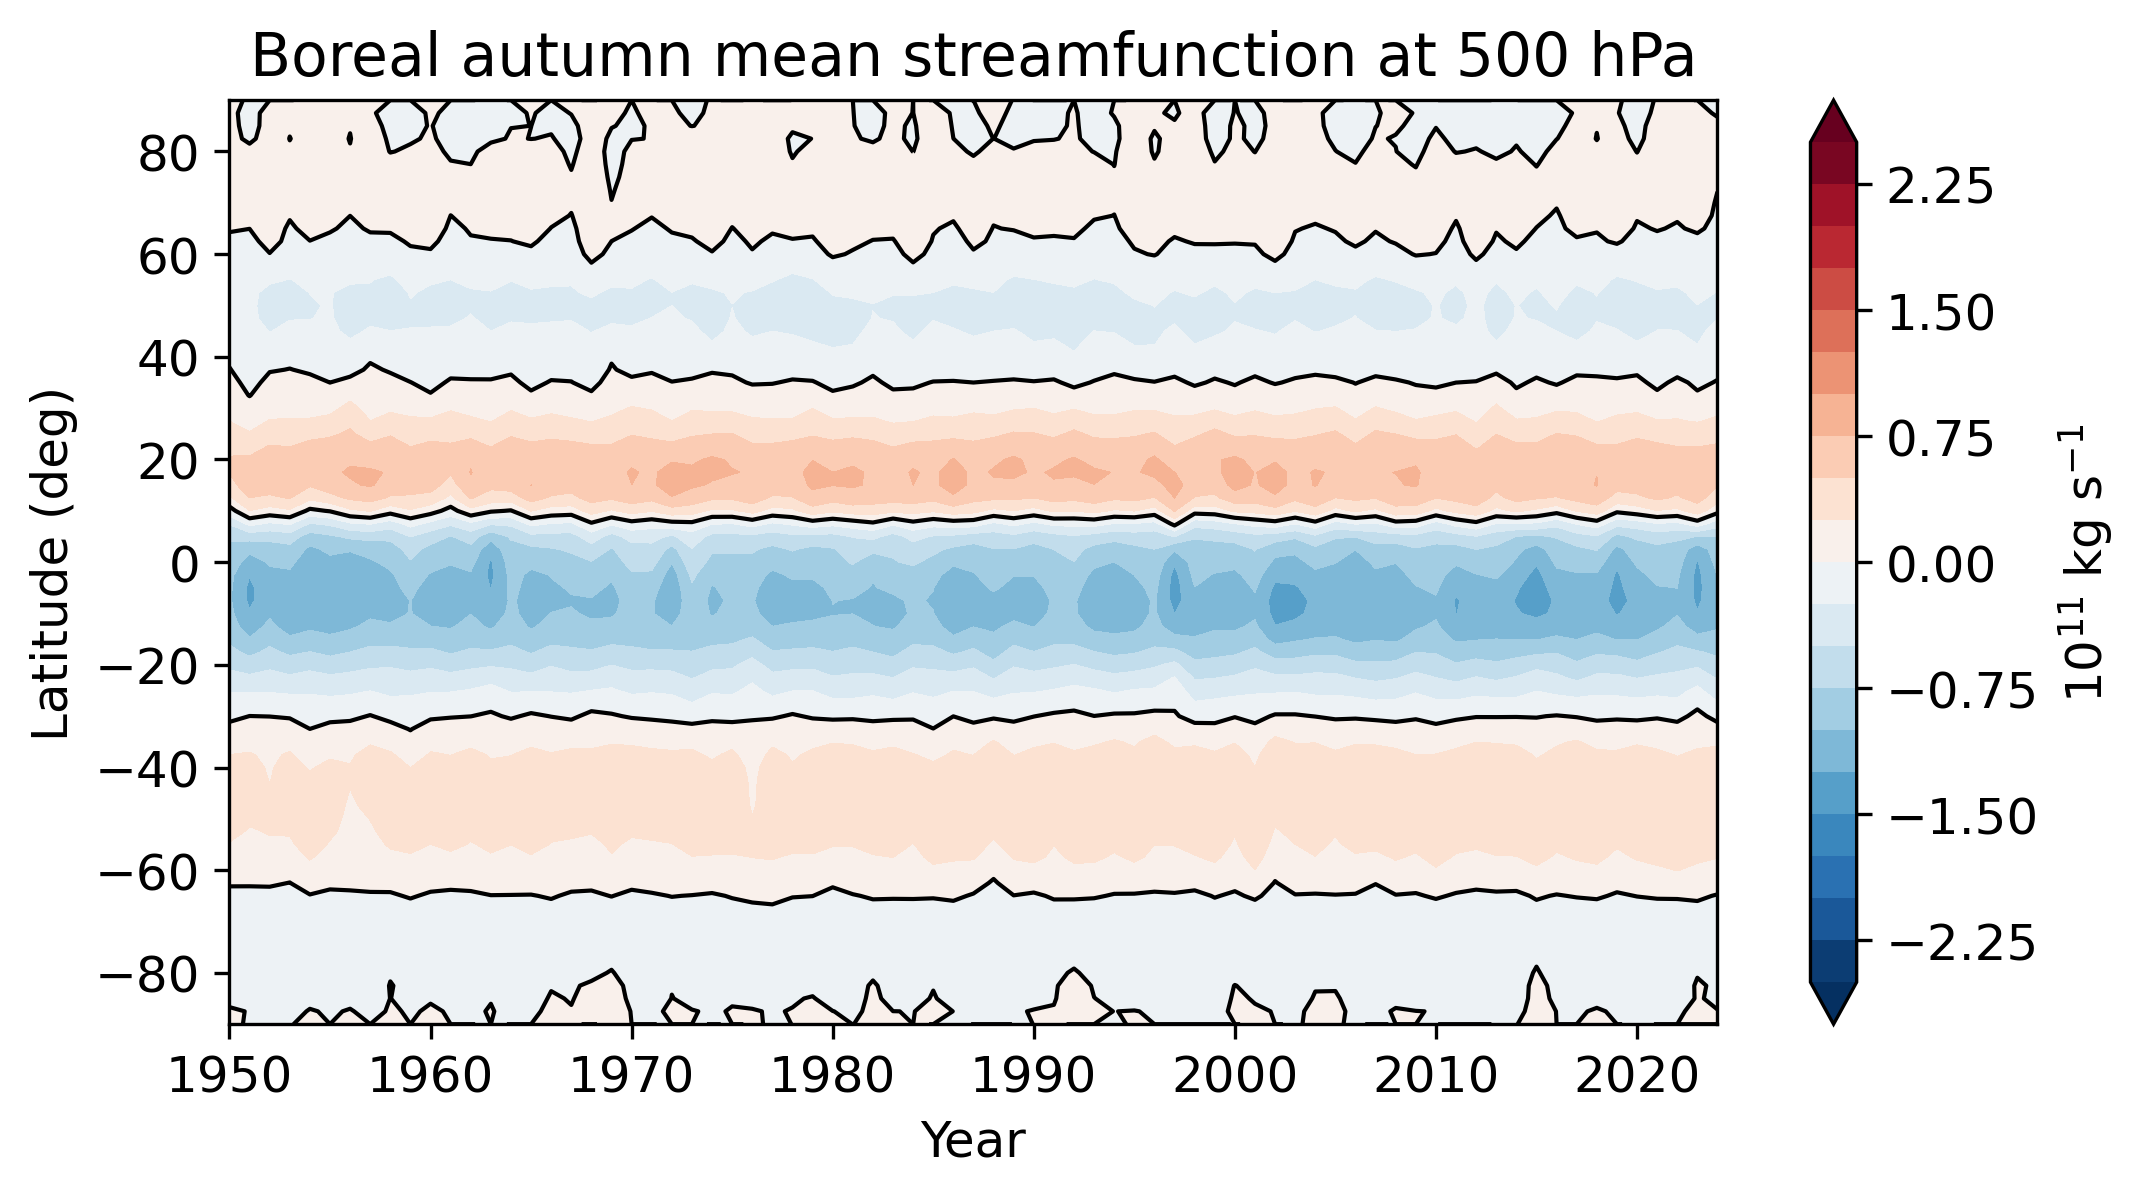

Inspect whether the zero contour or streamfunction core shifts poleward over time.


In [6]:
# Year-latitude section at 500 hPa.
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
psi_500_plot = psi_500 / 1e11
levels = np.linspace(-2.5, 2.5, 21)
cf = ax.contourf(
    psi_500_plot["year"],
    psi_500_plot["lat"],
    psi_500_plot.transpose("lat", "year"),
    levels=levels,
    cmap="RdBu_r",
    extend="both",
)
ax.contour(
    psi_500_plot["year"],
    psi_500_plot["lat"],
    psi_500_plot.transpose("lat", "year"),
    levels=[0],
    colors="black",
    linewidths=1.0,
)
ax.set_xlabel("Year")
ax.set_ylabel("Latitude (deg)")
ax.set_title("Boreal autumn mean streamfunction at 500 hPa")
fig.colorbar(cf, ax=ax, label=r"$10^{11}$ kg s$^{-1}$")
plt.show()

print("Inspect whether the zero contour or streamfunction core shifts poleward over time.")